In [1]:
import pandas as pd
from prophet import Prophet
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
from pyspark.ml.feature import Bucketizer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

In [2]:
spark=SparkSession.builder.appName('Practice').getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/09 09:16:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
data=spark.read.format('csv')\
     .option("header","true")\
      .option("inferSchema","true")\
        .option("path","/kaggle/input/face-data/face_analytics_data (1).csv")\
            .load()

In [4]:
new_data=data.withColumn("Time Difference", F.unix_timestamp("last_seen")-F.unix_timestamp("first_seen"))

In [5]:
new_data.limit(10).show()

+-----------+------+---------+----------+-------------------+-------------------+---------------+
|   face_uid|gender|age_range|confidence|         first_seen|          last_seen|Time Difference|
+-----------+------+---------+----------+-------------------+-------------------+---------------+
|FACE_956677|female|    60-98|   69.1974|2025-12-25 13:20:51|2025-12-25 13:21:09|             18|
|FACE_614740|  male|    42-48|   86.1852|2025-10-05 05:17:58|2025-10-05 05:18:09|             11|
|FACE_859680|  male|    25-30|   60.8019|2025-11-06 08:06:00|2025-11-06 08:06:03|              3|
|FACE_356096|female|    06-20|   93.7874|2025-01-25 17:20:44|2025-01-25 17:20:46|              2|
|FACE_509714|female|    06-20|   71.6826|2025-05-06 21:09:46|2025-05-06 21:09:57|             11|
|FACE_882809|  male|    42-48|   77.1883|2025-11-18 13:52:59|2025-11-18 13:53:20|             21|
|FACE_833457|  male|    25-30|   66.5352|2025-07-04 03:40:44|2025-07-04 03:40:50|              6|
|FACE_943292|female|

In [6]:
new_data.printSchema()

root
 |-- face_uid: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age_range: string (nullable = true)
 |-- confidence: double (nullable = true)
 |-- first_seen: timestamp (nullable = true)
 |-- last_seen: timestamp (nullable = true)
 |-- Time Difference: long (nullable = true)



# Average Confidence

In [7]:
new_data.groupBy("gender").agg(F.round(F.mean("confidence"),2).alias("Avg Confidence"),F.count('gender').alias("Total Count")).show()

+------+--------------+-----------+
|gender|Avg Confidence|Total Count|
+------+--------------+-----------+
|female|          79.0|    5000424|
|  male|          79.0|    4999576|
+------+--------------+-----------+



*Both Gender has considerably good average confidence in prediction and the population doesn't seem skewed against specific gender by this count column*

# Average Time Difference

In [8]:
new_data.groupby("age_range").agg(F.mean("Time Difference").alias("Avg. Age Range")).show()

+---------+------------------+
|age_range|    Avg. Age Range|
+---------+------------------+
|    25-30|15.001337835942474|
|    42-48| 14.99480182846314|
|    06-20|15.004420680245738|
|    60-98| 14.99635491464815|
+---------+------------------+



*The Average Time Difference is 15 seconds across the different age ranges*

# Count Based On Age Range

In [9]:
new_data.groupBy("gender").pivot("age_range").agg(F.count('gender')).show()

+------+-------+-------+-------+-------+
|gender|  06-20|  25-30|  42-48|  60-98|
+------+-------+-------+-------+-------+
|female|1248921|1250759|1250130|1250614|
|  male|1248206|1251790|1249018|1250562|
+------+-------+-------+-------+-------+



**Gender and Age has no skewness**

# When Users Visits in a day?

In [10]:
hour_data=new_data.select('first_seen','face_uid').withColumn('hour',F.date_format(F.col('first_seen'),"HH").cast('integer'))\
.withColumn('date',F.date_format(F.col('first_seen'),"yyyy-MM-dd")).select("face_uid","date","hour")
hour_data.printSchema()

root
 |-- face_uid: string (nullable = true)
 |-- date: string (nullable = true)
 |-- hour: integer (nullable = true)



## Splitting the 24 hours to 4 quarters 

In [11]:
splits=[0,6,12,18,24]
bucketizer=Bucketizer(splits=splits,inputCol="hour",outputCol="Bucket")
new_df=bucketizer.transform(hour_data)
splits_labels=F.array(F.lit("0-6"),F.lit("6-12"),F.lit("12-18"),F.lit("18-24"))
new_df=new_df.withColumn("time_quarters",splits_labels[F.col("Bucket").cast('integer')])
curated_hour_data=new_df.select('face_uid','time_quarters','date')
hour_df=curated_hour_data.dropDuplicates().groupBy("time_quarters").agg(F.count("time_quarters").alias("counts")).toPandas()

26/01/09 09:18:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:18:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:18:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:18:14 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:18:14 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:18:14 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:18:15 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:18:15 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:18:26 WARN RowBasedKeyValueBatch: Calling spill() on

In [12]:
hour_df

,time_quarters,counts
0,12-18,2489546
1,6-12,2491393
2,0-6,2493239
3,18-24,2491937


**So the customer store visit is independent of time as well**

# DAU

In [13]:
new_data.createOrReplaceTempView("audience_table")

In [14]:
daily_count=spark.sql("""select date_format(to_date(first_seen),'yyyy-MM-dd') as date,
count(distinct face_uid) as face_counts from audience_table group by 1 order by 1
""").toPandas()

26/01/09 09:19:12 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:19:12 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:19:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:19:14 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:19:42 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:19:42 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:19:42 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:19:42 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:19:42 WARN RowBasedKeyValueBatch: Calling spill() on

In [15]:
monthly_count=spark.sql("""select date_format(to_date(first_seen),'yyyy-MM') as date,
count(distinct face_uid) as face_counts from audience_table group by 1 order by 1
""").toPandas()

26/01/09 09:20:04 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:04 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:04 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:04 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:30 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:30 WARN RowBasedKeyValueBatch: Calling spill() on

In [16]:
daily_count.set_index('date')

,face_counts
date,
2025-01-01,27295
2025-01-02,27343
2025-01-03,26961
2025-01-04,27087
2025-01-05,26968
...,...
2025-12-27,27134
2025-12-28,26923
2025-12-29,27006


*Daily Active Users is count of unique users per day : Helps to measure the real engagement*

In [17]:
monthly_count

,date,face_counts
0,2025-01,572289
1,2025-02,535764
2,2025-03,572154
3,2025-04,560187
4,2025-05,573050
5,2025-06,560358
6,2025-07,571958
7,2025-08,571631
8,2025-09,560999
9,2025-10,572217


*Monthly Active Users is count of unique users per month : Helps to track the sales status*

In [18]:
monthly_gender_count=spark.sql("""select date_format(to_date(first_seen),'yyyy-MM') as date,gender,
count(distinct face_uid) as face_counts from audience_table group by 1,2 order by 1
""").toPandas()

26/01/09 09:20:47 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:47 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:47 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:47 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:47 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:48 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:48 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:20:48 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:21:20 WARN RowBasedKeyValueBatch: Calling spill() on

In [19]:
monthly_gender_count

,date,gender,face_counts
0,2025-01,female,346582
1,2025-01,male,345304
2,2025-02,male,318343
3,2025-02,female,318945
4,2025-03,male,345961
5,2025-03,female,345814
6,2025-04,male,337154
7,2025-04,female,336421
8,2025-05,female,346266
9,2025-05,male,346727


Text(0.5, 1.0, 'Customer Visit Trend')

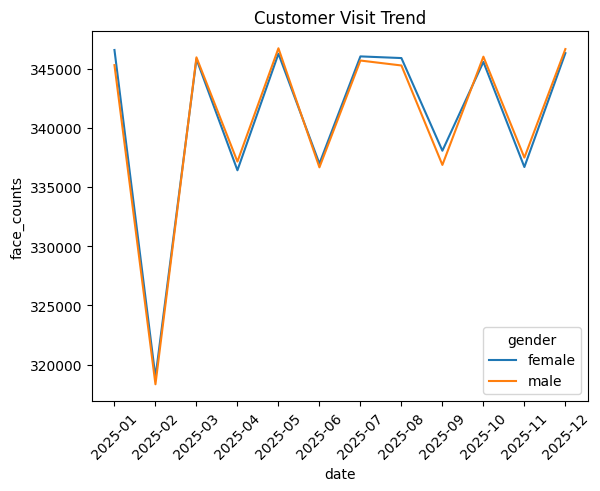

In [20]:
import seaborn as sns
sns.lineplot(data=monthly_gender_count,x='date',y='face_counts',hue='gender')
plt.xticks(rotation=45)
plt.title("Customer Visit Trend")

*This Show Customer visit was very low in febraury month*

# Most Visited Customers

In [21]:
spark.sql("""with unique_customer as 
(select distinct date_format(to_date(first_seen),'yyyy-MM-dd') as date,face_uid from audience_table)
select face_uid,dense_rank() over(order by count(face_uid) desc) as rnk,count(face_uid) as cnt from unique_customer  group by face_uid order by 2 limit 10
""").toPandas()

26/01/09 09:21:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/09 09:21:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/09 09:21:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/09 09:21:47 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:21:47 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:21:47 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:21:48 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/01/09 09:22:12 WARN WindowExec: No

,face_uid,rnk,cnt
0,FACE_621357,1,29
1,FACE_433649,2,28
2,FACE_919496,3,27
3,FACE_939873,3,27
4,FACE_714067,3,27
5,FACE_527173,4,26
6,FACE_411371,4,26
7,FACE_585695,4,26
8,FACE_135695,4,26
9,FACE_392982,4,26


**These are all the frequent buyers**

# Data Preparation

In [22]:
training_data=daily_count.copy()
training_data.columns=['ds','y']
training_data['ds']=pd.to_datetime(training_data['ds'],errors='coerce')

In [23]:
# fig=plt.figure(figsize=(20,10))
# ax= fig.add_axes([1,1,1,])
training_data.set_index('ds')

,y
ds,
2025-01-01,27295
2025-01-02,27343
2025-01-03,26961
2025-01-04,27087
2025-01-05,26968
...,...
2025-12-27,27134
2025-12-28,26923
2025-12-29,27006


**There was a huge crash in Jan , It was an unpredictable event and effects our output so we are trimming the data to feb**

In [24]:
training_data=training_data[training_data['ds']>'2025-02']

# Smoothing

In [25]:
training_data['y']=training_data['y'].rolling(window=7,min_periods=1).mean()

*Smoothing reduces the extreme values that is useful for forecasting*

# Prophet Model

In [26]:
model=Prophet()

In [27]:
model.fit(training_data)

09:22:34 - cmdstanpy - INFO - Chain [1] start processing
09:22:34 - cmdstanpy - INFO - Chain [1] done processing


In [28]:
NO_OF_DAYS=10
future=model.make_future_dataframe(NO_OF_DAYS)
forecast=model.predict(future)

In [29]:
predicted=forecast[['ds','trend','yhat','yhat_lower','yhat_upper']]

In [30]:
predicted_values=predicted[['ds','yhat']].tail(NO_OF_DAYS)

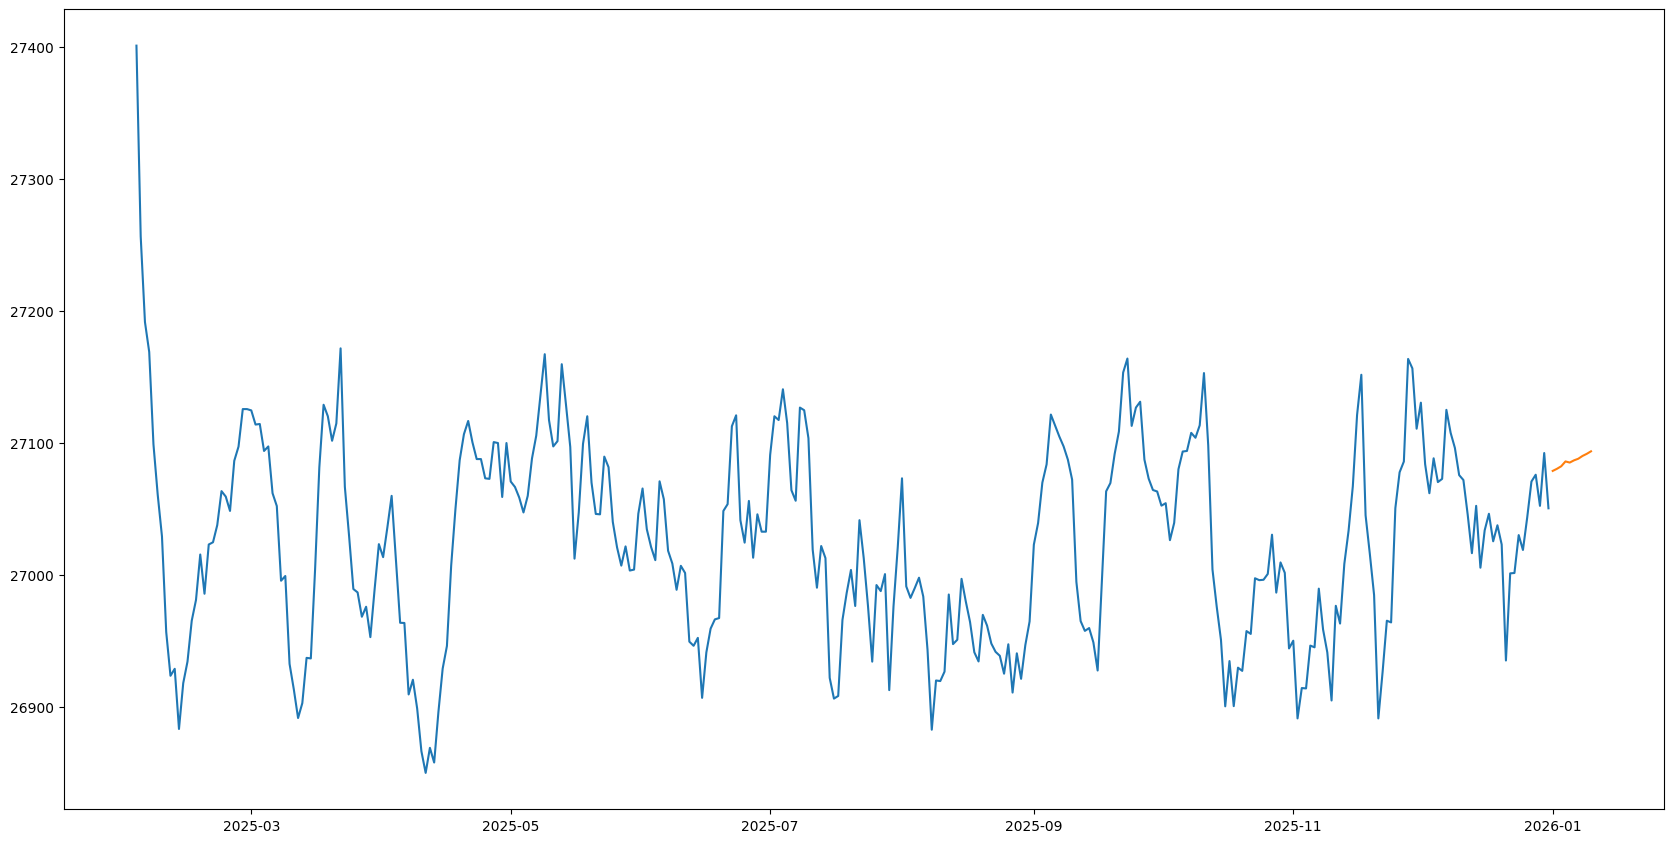

In [31]:

fig = plt.figure(figsize=(20,10))

axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])  
axes.plot(training_data['ds'],training_data['y'],label='Actual')
axes.plot(predicted_values['ds'],predicted_values['yhat'],label='predicted')

# Linear Regression

In [32]:
model=LinearRegression()

In [33]:
y=training_data["y"]
x=np.array(y.index).reshape(-1,1)

In [34]:
model.fit(x,y)

LinearRegression()

*Linear Regression model for Trend Analysis*

In [35]:
pred_data=np.arange(366,390).reshape(-1,1)
x_pred=np.append(x,pred_data).reshape(-1,1)
y_pred=model.predict(x_pred)

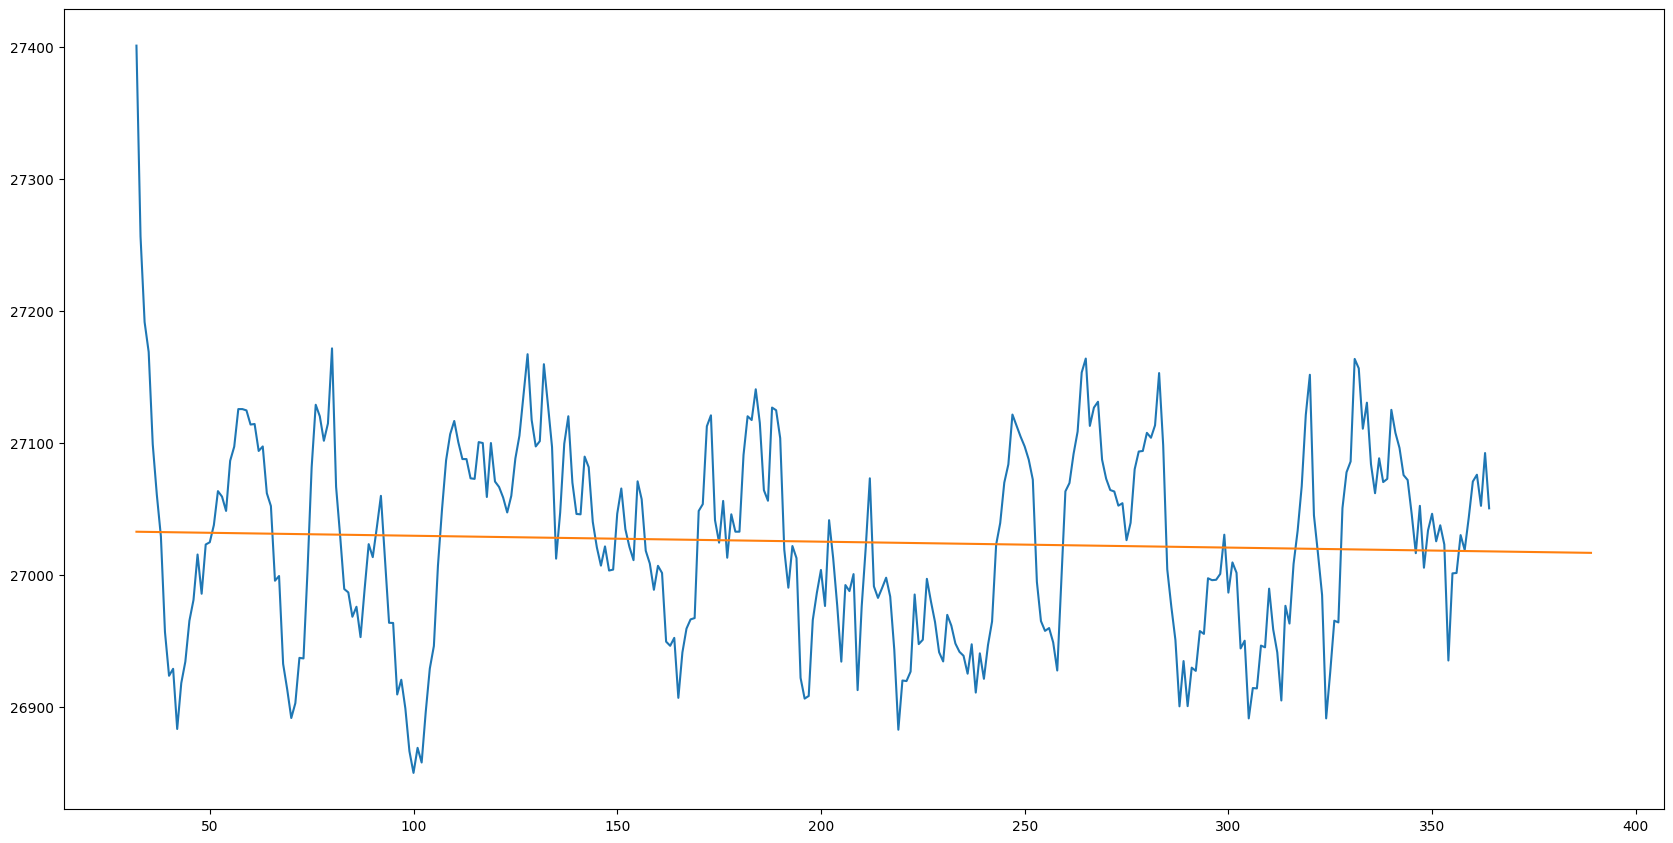

In [36]:

fig = plt.figure(figsize=(20,10))

axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])  
axes.plot(x,y,label='Actual')
axes.plot(x_pred,y_pred,label='predicted')

*It clearly show the stable micro decrease of footfall over months. Noise contibutes the spikes for daily footfall*